# Introdução

A análise por transformada de Fourier é o principal mecanismo para identificar os espectros das frequências das imagens. Através dela também, podemos realizar a aplicação de filtros apenas com a multiplicação no domínio da frequência.

# Utilizando a fft
## Testes iniciais

Para visualizar o espectro de frequencias de uma imagem, podemos

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [16]:
def mostrar(imagens: list, titulos=[], cmaps=[], eixos = False, minmax=None):
    if type(imagens) == list:
        if type(imagens[0]) == list:
            fig, axs = plt.subplots(len(imagens), len(imagens[0]), figsize=(5*len(imagens[0]), 5*len(imagens)))
            for i in range(len(imagens)):
                for j in range(len(imagens[i])):
                    imagem = imagens[i][j]
                    if cmaps[i][j]:
                        axs[i][j].imshow(imagem, cmap=cmaps[i][j])
                    else:
                        axs[i][j].imshow(imagem)
                    if titulos[i][j]:
                        axs[i][j].set_title(titulos[i][j])
                    if not eixos:
                        axs[i][j].axis("off")
        else:
            fig, axs = plt.subplots(1, len(imagens), figsize=(20, 20))
            for i, imagem in enumerate(imagens):
                if cmaps:
                    axs[i].imshow(imagem, cmap=cmaps[i])
                else:
                    axs[i].imshow(imagem)
                if titulos:
                    axs[i].set_title(titulos[i])
                if not eixos:
                    axs[i].axis("off")
        #diminui distancia lateral
        plt.subplots_adjust(wspace=0.1, hspace=0.1)
    else:
        if type(cmaps) != list:
            plt.imshow(imagens, cmap=cmaps)
        else:
            plt.imshow(imagens)
        if type(titulos) != list:
            plt.title(titulos)
        if not eixos:
            plt.axis("off")
    plt.show()
    

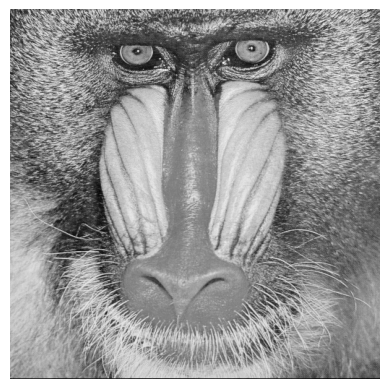

In [6]:
# carrega a imagem baboon.png usando cv2
img = cv2.imread('imagens/baboon.png')[:,:,0]
# exibe a imagem usando matplotlib
mostrar(img, cmaps='gray')


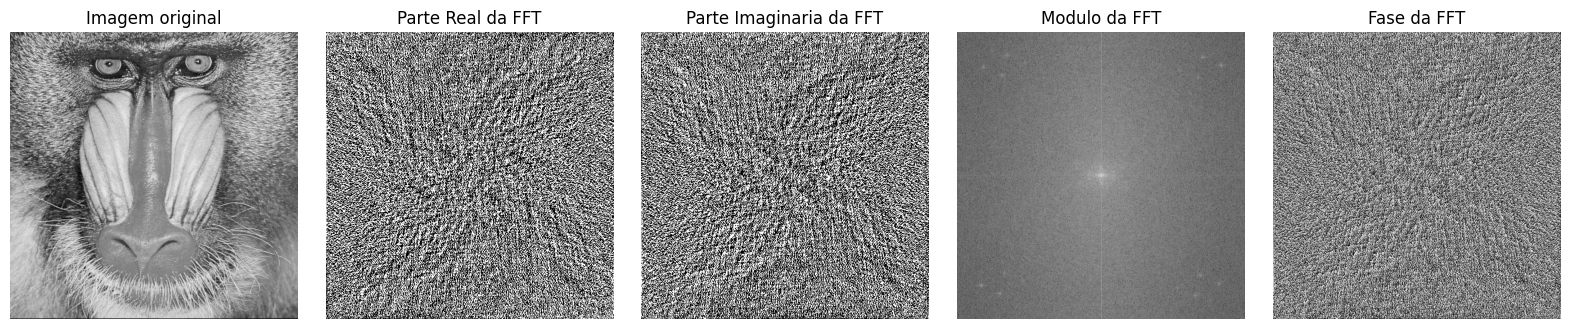

In [30]:
import numpy as np
# obtem a fft da imagem:
img_fft_not_shiff = np.fft.fft2(img)
img_fft = np.fft.fftshift(img_fft_not_shiff)
img_fft_modulo =np.abs(img_fft)

# exibe a parte real, a parte imaginaria, o modulo e a fase da fft da imagem
mostrar([img,np.clip(np.real(img_fft_not_shiff),0,255), np.clip(np.imag(img_fft_not_shiff),0,255), np.log1p(np.abs(img_fft)), np.angle(img_fft_not_shiff)], ["Imagem original","Parte Real da FFT", "Parte Imaginaria da FFT", "Modulo da FFT", "Fase da FFT"], ["gray"]*5)
